<a href="https://colab.research.google.com/github/martinnyamu/CSA-809---Deep-Learning/blob/main/Module_6_Mastery_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu


100%|██████████| 170M/170M [00:01<00:00, 87.5MB/s]



Training Model A...
Epoch 1: Train Acc = 50.19%, Val Acc = 59.59%
Epoch 2: Train Acc = 65.20%, Val Acc = 67.89%

Training Model B...
Epoch 1: Train Acc = 39.74%, Val Acc = 55.30%
Epoch 2: Train Acc = 50.05%, Val Acc = 62.72%

--- Comparison ---
Model A Training Accuracy: [50.192, 65.202]
Model A Validation Accuracy: [59.59, 67.89]
Model A Training Time: 177.98 seconds

Model B Training Accuracy: [39.742, 50.052]
Model B Validation Accuracy: [55.3, 62.72]
Model B Training Time: 219.04 seconds


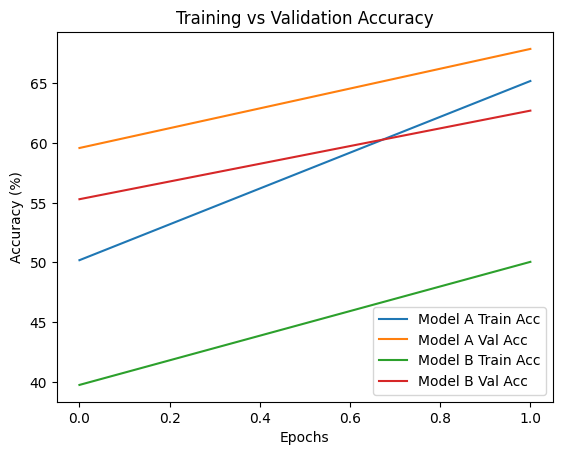


--- Overfitting Check ---
Model A Overfitting Gap: -2.6880000000000024
Model B Overfitting Gap: -12.668

Interpretation:
- Larger gap = more overfitting
- Model B should generalize better due to BatchNorm + Dropout


In [2]:
# CIFAR-10 CNN Comparison: Basic vs BatchNorm + Dropout

# 1. Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2. Load CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform)

val_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# 3. Define Models

# Model A: Basic CNN
class CNN_A(nn.Module):
    def __init__(self):
        super(CNN_A, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64*8*8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64*8*8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Model B: CNN with BatchNorm + Dropout
class CNN_B(nn.Module):
    def __init__(self):
        super(CNN_B, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64*8*8, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64*8*8)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Training function
def train_model(model, train_loader, val_loader, epochs=2):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    history = {"train_acc": [], "val_acc": [], "time": 0}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Train Acc = {train_acc:.2f}%, Val Acc = {val_acc:.2f}%")

    history["time"] = time.time() - start_time
    return history

# 4. Train both models
print("\nTraining Model A...")
model_a = CNN_A()
history_a = train_model(model_a, train_loader, val_loader)

print("\nTraining Model B...")
model_b = CNN_B()
history_b = train_model(model_b, train_loader, val_loader)

# 5. Compare Results
print("\n--- Comparison ---")
print("Model A Training Accuracy:", history_a['train_acc'])
print("Model A Validation Accuracy:", history_a['val_acc'])
print("Model A Training Time: %.2f seconds" % history_a['time'])

print("\nModel B Training Accuracy:", history_b['train_acc'])
print("Model B Validation Accuracy:", history_b['val_acc'])
print("Model B Training Time: %.2f seconds" % history_b['time'])

# Plot Accuracy vs Epochs
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_a['train_acc'], label='Model A Train Acc')
plt.plot(history_a['val_acc'], label='Model A Val Acc')
plt.plot(history_b['train_acc'], label='Model B Train Acc')
plt.plot(history_b['val_acc'], label='Model B Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Simple Overfitting Check
print("\n--- Overfitting Check ---")
print("Model A Overfitting Gap:", history_a['train_acc'][-1] - history_a['val_acc'][-1])
print("Model B Overfitting Gap:", history_b['train_acc'][-1] - history_b['val_acc'][-1])

print("\nInterpretation:")
print("- Larger gap = more overfitting")
print("- Model B should generalize better due to BatchNorm + Dropout")
